In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from src.data_preprocessing import *

In [3]:
df = load_dataset('../../data/processed/cardio_train.csv', sep=',')
print(type(df))
df.head()

<class 'pandas.DataFrame'>


,age,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,gender_male,BMI
0,50,168,62.0,110,80,1,1,0,0,1,0,0,21.967120
1,55,156,85.0,140,90,3,1,0,0,1,1,1,34.927679
2,51,165,64.0,130,70,3,1,0,0,0,1,1,23.507805
3,48,169,82.0,150,100,1,1,0,0,1,1,0,28.710479
4,47,156,56.0,100,60,1,1,0,0,0,0,1,23.011177


In [4]:
df.describe()

,age,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,gender_male,BMI
count,68606.000000,68606.000000,68606.000000,68606.000000,68606.00000,68606.000000,68606.000000,68606.000000,68606.000000,68606.000000,68606.000000,68606.000000,68606.000000
mean,52.828514,164.409454,74.086303,126.671005,81.30576,1.364793,1.225811,0.087966,0.053334,0.803326,0.494723,0.651313,27.448172
std,6.768806,7.941311,14.212777,16.688603,9.45360,0.678996,0.571659,0.283248,0.224699,0.397486,0.499976,0.476558,5.211817
min,29.000000,100.000000,28.000000,60.000000,40.00000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.726644
25%,48.000000,159.000000,65.000000,120.000000,80.00000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,23.875115
50%,53.000000,165.000000,72.000000,120.000000,80.00000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,26.346494
75%,58.000000,170.000000,82.000000,140.000000,90.00000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,30.116213
max,64.000000,250.000000,200.000000,240.000000,182.00000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,60.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68606 entries, 0 to 68605
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          68606 non-null  int64  
 1   height       68606 non-null  int64  
 2   weight       68606 non-null  float64
 3   ap_hi        68606 non-null  int64  
 4   ap_lo        68606 non-null  int64  
 5   cholesterol  68606 non-null  int64  
 6   gluc         68606 non-null  int64  
 7   smoke        68606 non-null  int64  
 8   alco         68606 non-null  int64  
 9   active       68606 non-null  int64  
 10  cardio       68606 non-null  int64  
 11  gender_male  68606 non-null  int64  
 12  BMI          68606 non-null  float64
dtypes: float64(2), int64(11)
memory usage: 6.8 MB


In [6]:
df.shape

(68606, 13)

Text(0.5, 1.0, 'Cas cardiaques')

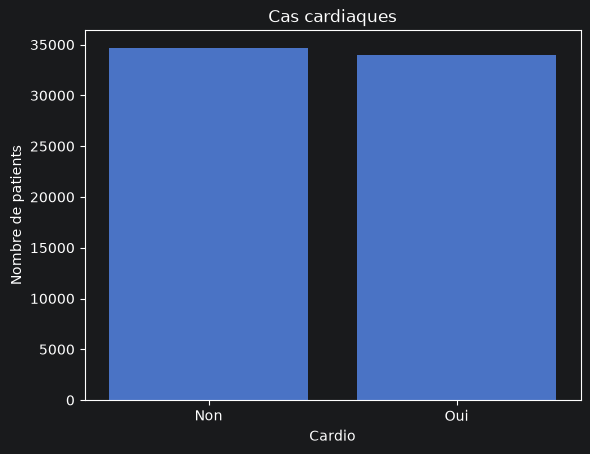

In [59]:
sns.countplot(data=df, x="cardio")
plt.xticks([0, 1], ["Non", "Oui"])
plt.ylabel("Nombre de patients")
plt.xlabel("Cardio")
plt.title("Cas cardiaques")

Text(0.5, 1.0, 'Cas cardiaques par genre')

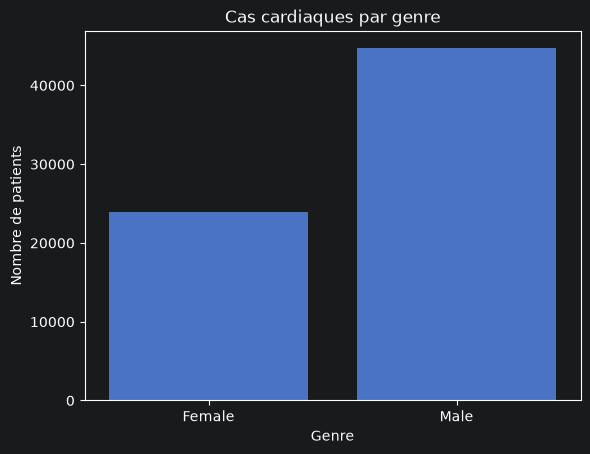

In [60]:
sns.countplot(data=df, x="gender_male")
plt.xticks([0, 1], ["Female", "Male"])
plt.ylabel("Nombre de patients")
plt.xlabel("Genre")
plt.title("Cas cardiaques par genre")

Text(0.5, 1.0, 'Répartition des patients par age et genre')

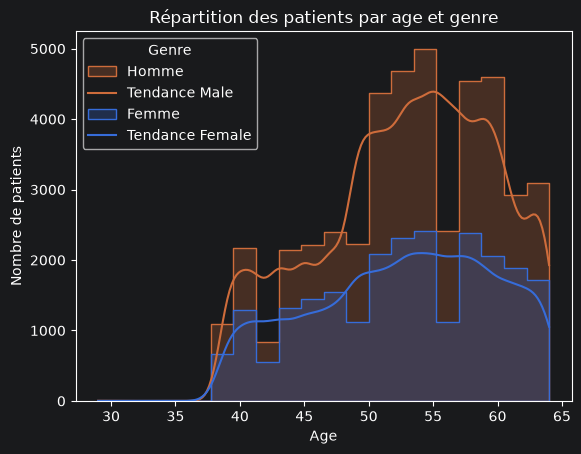

In [49]:
sns.histplot(
    data=df,
    x="age",
    hue="gender_male",
    kde=True,
    bins=20,
    element="step"
)
plt.ylabel("Nombre de patients")
plt.xlabel("Age")
plt.legend(
    title="Genre",
    labels=["Homme", "Tendance Male", "Femme", "Tendance Female"]
)
plt.title("Répartition des patients par age et genre")

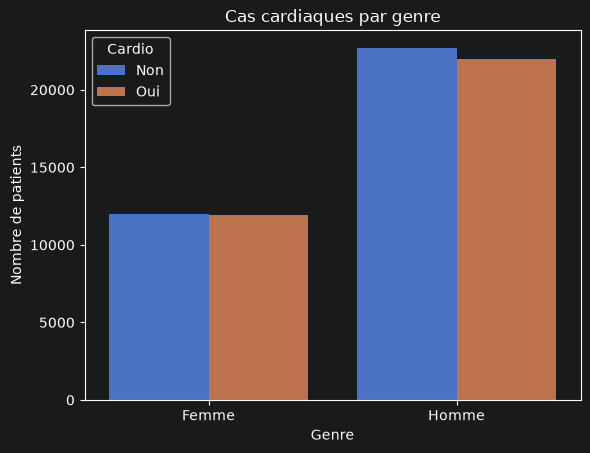

In [71]:
sns.countplot(
    data=df,
    x="gender_male",
    hue="cardio",
)
plt.xticks([0, 1], ["Femme", "Homme"])
plt.xlabel("Genre")
plt.ylabel("Nombre de patients")
plt.title("Cas cardiaques par genre")
plt.legend(title="Cardio", labels=["Non", "Oui"])

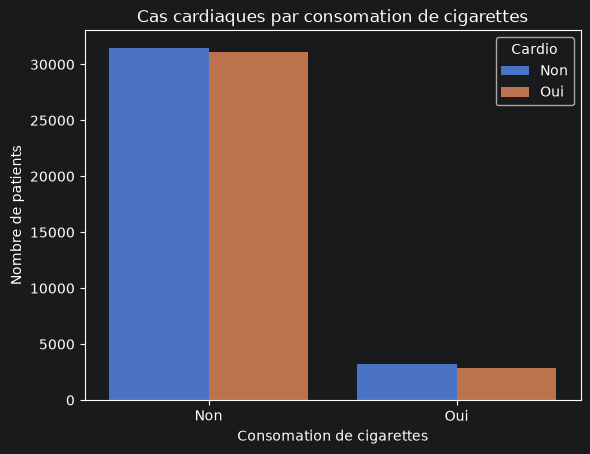

In [55]:
sns.countplot(
    data=df,
    x="smoke",
    hue="cardio"
)
plt.xticks([0, 1], ["Non", "Oui"])
plt.ylabel("Nombre de patients")
plt.xlabel("Consomation de cigarettes")
plt.title("Cas cardiaques par consomation de cigarettes")
plt.legend(title="Cardio", labels=["Non", "Oui"])

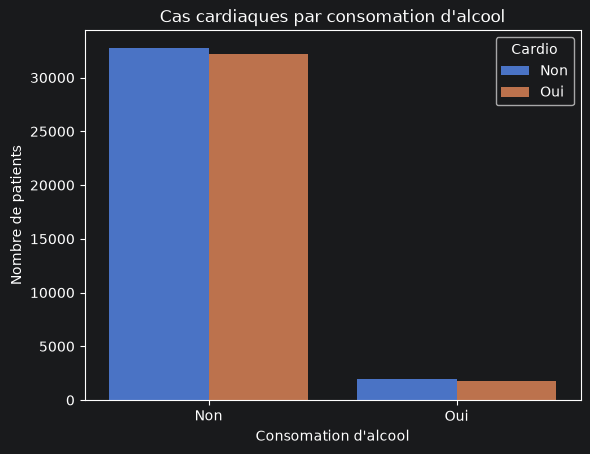

In [54]:
sns.countplot(
    data=df,
    x="alco",
    hue="cardio",
)
plt.xticks([0, 1], ["Non", "Oui"])
plt.ylabel("Nombre de patients")
plt.xlabel("Consomation d'alcool")
plt.title("Cas cardiaques par consomation d'alcool")
plt.legend(title="Cardio", labels=["Non", "Oui"])

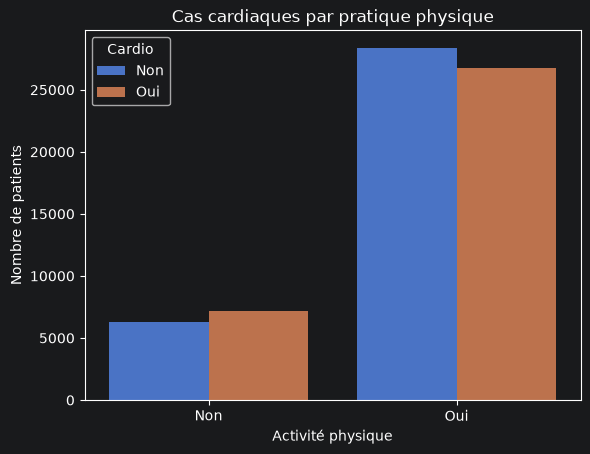

In [53]:
sns.countplot(
    data=df,
    x="active",
    hue="cardio"
)
plt.xticks([0, 1], ["Non", "Oui"])
plt.ylabel("Nombre de patients")
plt.xlabel("Activité physique")
plt.title("Cas cardiaques par pratique physique")
plt.legend(title="Cardio", labels=["Non", "Oui"])

Cas extrêmes (ap_hi > 180) : 283


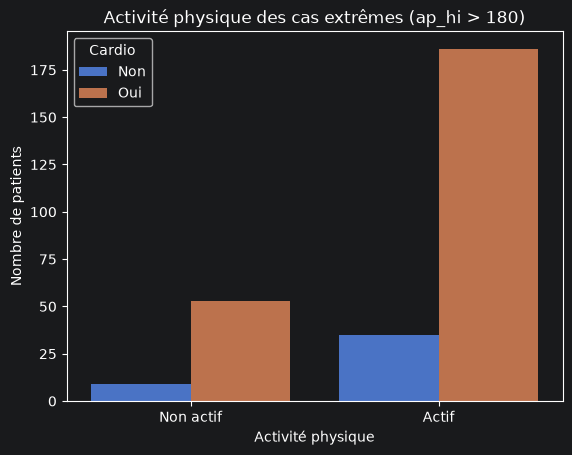

In [69]:
df_extreme = df[df["ap_hi"] > 180].copy()
print(f"Cas extrêmes (ap_hi > 180) : {len(df_extreme)}")

sns.countplot(
    data=df_extreme,
    x="active",
    hue="cardio"
)
plt.xticks([0, 1], ["Non actif", "Actif"])
plt.xlabel("Activité physique")
plt.ylabel("Nombre de patients")
plt.title("Activité physique des cas extrêmes (ap_hi > 180)")
plt.legend(title="Cardio", labels=["Non", "Oui"])

La majorité des patients qui ont plus de 180 mmHg en préssion Systolic pratique des activité physique et présente des maladies cardiovasculaire

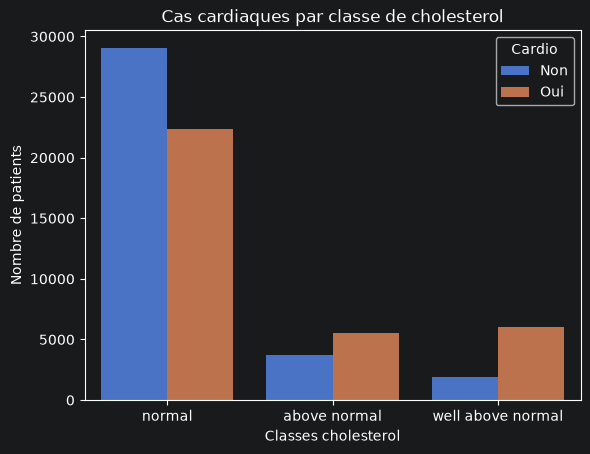

In [52]:
sns.countplot(
    data=df,
    x="cholesterol",
    hue="cardio",
)
plt.xticks([0, 1, 2], ["normal", "above normal", "well above normal"])
plt.ylabel("Nombre de patients")
plt.xlabel("Classes cholesterol")
plt.title("Cas cardiaques par classe de cholesterol")
plt.legend(title="Cardio", labels=["Non", "Oui"])

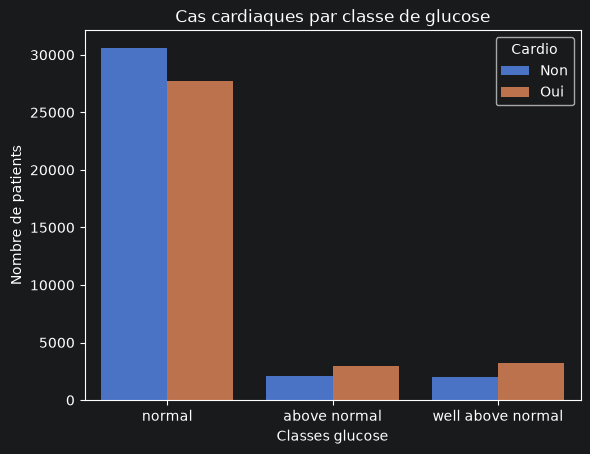

In [50]:
sns.countplot(
    data=df,
    x="gluc",
    hue="cardio",
)
plt.xticks([0, 1, 2], ["normal", "above normal", "well above normal"])
plt.ylabel("Nombre de patients")
plt.xlabel("Classes glucose")
plt.title("Cas cardiaques par classe de glucose")
plt.legend(title="Cardio", labels=["Non", "Oui"])